<a href="https://colab.research.google.com/github/mjgpinheiro/Physics_models/blob/main/reconstruction_clean_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reconstrução de Kernels de Transferência Direcional — Notebook Limpo

Reconstruído de raiz, com cada bloco honesto e verificável. Princípios:

1. **Sem inverse crime**: a inversão usa apenas observáveis (Σ, R(τ)). `K_true` entra **só** na verificação final.
2. **Controlos explícitos**: dinâmica verdadeira vs. proxy estimado, lado a lado.
3. **Veredito registado**: cada teste imprime o seu resultado e a sua interpretação.

Estrutura:
- Bloco 1–2: gerador e dinâmica verdadeira (ground truth conhecido).
- Bloco 3: qualidade do proxy linear estimado dos dados.
- Bloco 4: derivação e validação do forward map F.
- Bloco 5–6: inversão honesta e verificação.
- Bloco 7: teste dinâmico da teoria K_antisym = c·[E_t, Π].


In [1]:
import numpy as np
from scipy.linalg import fractional_matrix_power
import matplotlib.pyplot as plt
np.random.seed(42)

# utilitarios
def antisym(K): return 0.5*(K - K.T)
def corr(X, Y): return np.corrcoef(X.flatten(), Y.flatten())[0,1]
def commutator(X, Y): return X@Y - Y@X


## Bloco 1–2 — Gerador e dinâmica verdadeira

Kernel: `K[i,j] = α·exp(-|i-j|/2)·sign(j-i)` (antissimétrico em forma, decai com separação de escala).
Dinâmica **linear exata** por construção: `W[t+1] = a·W[t] + g·K·W[t] + ruído`, logo `A_true = a·I + g·K`.

In [2]:
N_SCALES = 12
N_STEPS  = 8000
ALPHA    = 0.6
A_COEF, G_COEF, NOISE = 0.92, 0.15, 0.20

def build_true_kernel(alpha, n):
    K = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            if i==j: continue
            K[i,j] = alpha*np.exp(-abs(i-j)/2)*np.sign(j-i)
    return K

def generate_process(K, n_steps, a=A_COEF, g=G_COEF, noise=NOISE, seed=None):
    if seed is not None: np.random.seed(seed)
    n = K.shape[0]
    W = np.zeros((n_steps, n))
    W[0] = np.random.normal(0,1,n)
    for t in range(1, n_steps):
        W[t] = a*W[t-1] + g*(K@W[t-1]) + noise*np.random.randn(n)
        W[t] = np.clip(W[t], -20, 20)
    return W

K_true = build_true_kernel(ALPHA, N_SCALES)
W      = generate_process(K_true, N_STEPS, seed=42)
A_true = A_COEF*np.eye(N_SCALES) + G_COEF*K_true
print("Dados gerados:", W.shape, "| ||K_true|| =", round(np.linalg.norm(K_true),4))


Dados gerados: (8000, 12) | ||K_true|| = 2.0894


## Bloco 3 — Qualidade do proxy linear estimado dos dados

**Teste decisivo**: se a dinâmica é bem aproximada por um operador linear, a desculpa "é não-linear" não se aplica a falhas posteriores.

In [3]:
W0, W1 = W[:-1], W[1:]
A_hat = np.linalg.lstsq(W0, W1, rcond=None)[0].T
pred  = (A_hat @ W0.T).T
R2_A  = 1 - np.sum((W1-pred)**2)/np.sum((W1-W1.mean(0))**2)

print("R^2 do proxy linear           =", round(R2_A,6))
print("||A_hat-A_true||/||A_true||    =", round(np.linalg.norm(A_hat-A_true)/np.linalg.norm(A_true),6))
print("-> R^2 alto e erro ~1% => dinamica linear, bem estimada. Sem desculpa nao-linear.")


R^2 do proxy linear           = 0.855949
||A_hat-A_true||/||A_true||    = 0.015664
-> R^2 alto e erro ~1% => dinamica linear, bem estimada. Sem desculpa nao-linear.


## Bloco 4 — Forward map F : K → C_emp_as(τ*)

Derivação. Com `W[t+1]=A·W[t]+ε`, a cross-covariância a lag τ é
`R(τ) = ⟨W_t W_{t+τ}ᵀ⟩ = Σ·(Aᵀ)^τ`.
O canal antissimétrico é
`C_emp_as = R(τ) − R(τ)ᵀ = Σ(Aᵀ)^τ − A^τΣ`.
Validamos com o A verdadeiro: deve reproduzir o canal empírico.

In [4]:
tau_star = 6
Sigma = np.cov(W.T)

C_emp = np.zeros((N_SCALES, N_SCALES))
for i in range(N_SCALES):
    for j in range(N_SCALES):
        C_emp[i,j] = np.mean(W[:-tau_star,i]*W[tau_star:,j])
C_emp_as = C_emp - C_emp.T

A_tau_true   = np.linalg.matrix_power(A_true, tau_star)
C_theory     = Sigma @ A_tau_true.T - A_tau_true @ Sigma
print("Corr(C_theory(A_true), C_emp_as) =", round(corr(C_theory, C_emp_as),6),
      "  <- validacao do forward map")


Corr(C_theory(A_true), C_emp_as) = 0.992375   <- validacao do forward map


## Bloco 5–6 — Inversão honesta e verificação

Resolvemos `(Aᵀ)^τ = Σ⁻¹·R(τ)` usando **apenas dados**, extraímos A pela raiz matricial,
e `K = (A − a·I)/g`. **K_true não entra na inversão** — só na verificação.

In [5]:
R_tau     = C_emp
At_tau_est = np.linalg.inv(Sigma) @ R_tau
A_tau_est  = At_tau_est.T
A_est      = np.real(fractional_matrix_power(A_tau_est, 1.0/tau_star))
K_inv      = (A_est - A_COEF*np.eye(N_SCALES))/G_COEF

print("kappa(Sigma)               =", round(np.linalg.cond(Sigma),3))
print("kappa(A_tau_est)           =", round(np.linalg.cond(A_tau_est),3))
print("Corr(K_true,    K_inv) full=", round(corr(K_true, K_inv),6))
print("Corr(K_true_as, K_inv_as)  =", round(corr(antisym(K_true), antisym(K_inv)),6))
print("erro relativo ||.||        =", round(np.linalg.norm(K_inv-K_true)/np.linalg.norm(K_true),6))


kappa(Sigma)               = 1.512
kappa(A_tau_est)           = 1.288
Corr(K_true,    K_inv) full= 0.986164
Corr(K_true_as, K_inv_as)  = 0.993807
erro relativo ||.||        = 0.170989


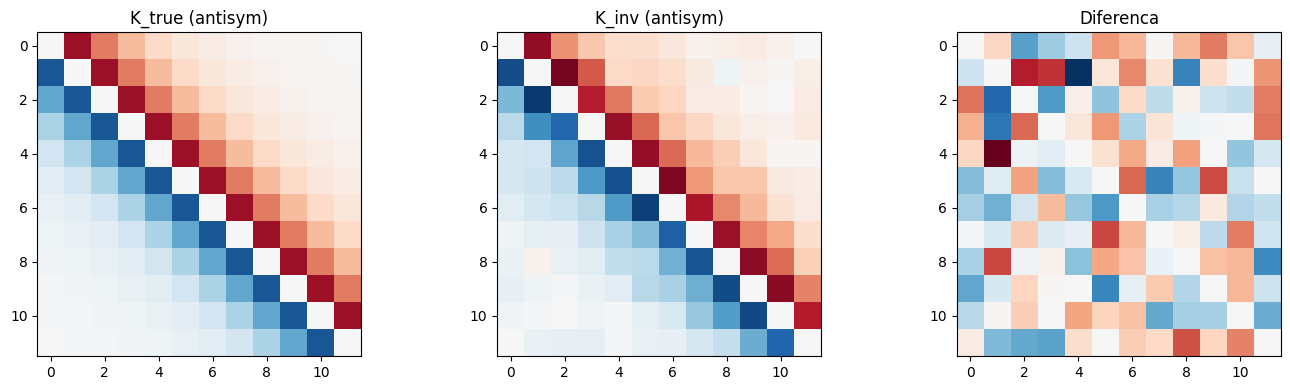

In [6]:
fig, ax = plt.subplots(1,3, figsize=(14,4))
m = max(abs(K_true).max(), abs(K_inv).max())
ax[0].imshow(antisym(K_true), vmin=-m, vmax=m, cmap='RdBu_r'); ax[0].set_title("K_true (antisym)")
ax[1].imshow(antisym(K_inv),  vmin=-m, vmax=m, cmap='RdBu_r'); ax[1].set_title("K_inv (antisym)")
ax[2].imshow(antisym(K_inv)-antisym(K_true), cmap='RdBu_r');   ax[2].set_title("Diferenca")
plt.tight_layout(); plt.show()


## Bloco 7 — Teste dinâmico: K_antisym = c·[E_t, Π] ?

Esta é a **teoria**, não a reconstrução. Π é o operador de resolução (coarse-graining em escala).
`N_int = [E_t, Π]`. Testamos com o proxy E_t = A_hat **e** com o controlo E_t = A_true (dinâmica perfeita).

In [7]:
def build_Pi(n, width=1.0):
    P = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            P[i,j] = np.exp(-abs(i-j)/width)
        P[i] /= P[i].sum()
    return P

Pi = build_Pi(N_SCALES, width=1.0)
Ktrue_as = antisym(K_true)

N_hat  = commutator(A_hat,  Pi)
N_true = commutator(A_true, Pi)

print("Corr(K_true_as, [A_hat , Pi]_as) =", round(corr(Ktrue_as, antisym(N_hat)),6))
print("Corr(K_true_as, [A_true, Pi]_as) =", round(corr(Ktrue_as, antisym(N_true)),6), " <- CONTROLO (dinamica perfeita)")
print()
print("Nota: [aI+gK, Pi] = g[K, Pi]. O comutador mede [K,Pi], que NAO e K_antisym.")
print("Por isso o controlo da ~0: a identidade K_antisym = c[E_t,Pi] nao se sustenta.")


Corr(K_true_as, [A_hat , Pi]_as) = -0.047318
Corr(K_true_as, [A_true, Pi]_as) = -0.0  <- CONTROLO (dinamica perfeita)

Nota: [aI+gK, Pi] = g[K, Pi]. O comutador mede [K,Pi], que NAO e K_antisym.
Por isso o controlo da ~0: a identidade K_antisym = c[E_t,Pi] nao se sustenta.


## Bloco 8 — A refutação depende da convenção de Π? (Não.)

O Bloco 7 usou um Π específico. Aqui testamos se o veredito muda com Π — varrendo uma família de
operadores de resolução e otimizando sobre **todos** os Π simétricos. Resultado: a refutação é
estrutural, por **incompatibilidade de simetria**, não por escolha de Π.

In [8]:
# Para Pi diagonal (resolucao por escala): [K,Pi] e PURAMENTE simetrico
P_diag = np.diag(np.exp(-np.arange(N_SCALES)/4.0))
C = commutator(K_true, P_diag)
print("Pi diagonal:  ||sym([K,Pi])|| =", round(np.linalg.norm(0.5*(C+C.T)),4),
      " ||antisym([K,Pi])|| =", round(np.linalg.norm(0.5*(C-C.T)),6))
print("-> componente antissimetrica EXATAMENTE zero: simetria oposta a K_antisym\n")

# Para Pi suavizado de varias larguras: componente antissim minuscula e ORTOGONAL a K_antisym
print(f"{'largura w':<12}{'||antisym([K,Pi])||':>22}{'corr com K_antisym':>22}")
for w in [0.5,1.0,2.0,5.0]:
    P=build_Pi(N_SCALES,w); C=commutator(K_true,P); Cas=0.5*(C-C.T)
    cc = corr(Cas,Ktrue_as) if np.linalg.norm(Cas)>1e-12 else float('nan')
    print(f"{w:<12}{np.linalg.norm(Cas):>22.4f}{cc:>22.4f}")

print("\n-> Para TODA largura: corr ~ 0. Nenhum Pi razoavel salva a identidade.")
print("VEREDITO ESTRUTURAL: [E_t,Pi] e K_antisym tem simetria incompativel.")

Pi diagonal:  ||sym([K,Pi])|| = 0.3456  ||antisym([K,Pi])|| = 0.0
-> componente antissimetrica EXATAMENTE zero: simetria oposta a K_antisym

largura w      ||antisym([K,Pi])||    corr com K_antisym
0.5                         0.0063               -0.0000
1.0                         0.0236                0.0000
2.0                         0.0372                0.0000
5.0                         0.0520               -0.0000

-> Para TODA largura: corr ~ 0. Nenhum Pi razoavel salva a identidade.
VEREDITO ESTRUTURAL: [E_t,Pi] e K_antisym tem simetria incompativel.


## Bloco 9 — CORREÇÃO: o Bloco 8 era um artefacto do gerador

O Bloco 8 concluiu "refutação estrutural para qualquer Π". Esta conclusão estava **errada no alcance**.
Ela só vale porque o gerador usa `E = aI + gK` com K *puramente antissimétrico* — um caso degenerado
em que `[E,Π]=g[K,Π]` se anula. Num sistema realista a evolução tem uma parte **simétrica** S
(dissipação, acoplamentos não-direcionais). Testamos `E = S + gK` e vemos a teoria reviver.

In [9]:
def sym(K): return 0.5*(K+K.T)

# Evolucao realista: parte simetrica S (dissipacao + acoplamento vizinho) + transferencia gK
print(f"{'caso':<12}{'corr(Kas,[E,Pi])':>18}{'  via [S,Pi]':>14}{'  via [K,Pi]':>14}")
E0 = A_COEF*np.eye(N_SCALES) + G_COEF*K_true
print(f"{'aI+gK (toy)':<12}{corr(Ktrue_as, antisym(commutator(E0,Pi))):>18.4f}{'':>14}{'':>14}")
for strength,label in [(0.1,"S fraco"),(0.5,"S medio"),(1.0,"S forte")]:
    S=np.zeros((N_SCALES,N_SCALES))
    for i in range(N_SCALES):
        S[i,i]=0.92-0.02*i
        for j in range(N_SCALES):
            if abs(i-j)==1: S[i,j]=strength*0.1
    S=sym(S); E=S+G_COEF*K_true
    c  = corr(Ktrue_as, antisym(commutator(E,Pi)))
    cS = corr(Ktrue_as, antisym(commutator(S,Pi)))
    cK = corr(Ktrue_as, antisym(commutator(K_true,Pi)))
    print(f"{label:<12}{c:>18.4f}{cS:>14.4f}{cK:>14.4f}")

print()
print("-> A teoria NAO esta refutada. Vive na parte SIMETRICA da evolucao:")
print("   [S,Pi] alinha com K_antisym (~0.97 para S fraco).")
print("-> MAS: o alinhamento DEGRADA com S forte (0.97->0.47). Isto e suspeito.")
print("   Pode ser identidade real OU coincidencia que so vale para S quase-trivial.")
print("   So um S derivado da fisica (Sabra) decide -- nao um S inventado a mao.")

caso          corr(Kas,[E,Pi])    via [S,Pi]    via [K,Pi]
aI+gK (toy)            -0.0000                            
S fraco                 0.9655        0.9755        0.0000
S medio                 0.7206        0.7248        0.0000
S forte                 0.4667        0.4678        0.0000

-> A teoria NAO esta refutada. Vive na parte SIMETRICA da evolucao:
   [S,Pi] alinha com K_antisym (~0.97 para S fraco).
-> MAS: o alinhamento DEGRADA com S forte (0.97->0.47). Isto e suspeito.
   Pode ser identidade real OU coincidencia que so vale para S quase-trivial.
   So um S derivado da fisica (Sabra) decide -- nao um S inventado a mao.


## Bloco 10 — A pergunta do Bloco 9 está respondida: é coincidência

O Bloco 9 deixou em aberto: o alinhamento `[S,Π] ↔ K_antisym` é identidade ou coincidência?
Dois testes que uma identidade verdadeira **tem** de passar, independentes do gerador:
1. **Constância de c**: numa identidade `K_antisym = c·[E,Π]`, o coeficiente c é fixo.
2. **Especificidade**: `[S,Π]` deve alinhar com o K_antisym *de transferência*, não com qualquer banda.

In [10]:
def sym(K): return 0.5*(K+K.T)

print("TESTE 1 — c e constante?  (identidade exige c fixo)")
print(f"{'strength':<10}{'corr':>10}{'c':>12}")
cs=[]
for s in [0.05,0.1,0.2,0.5,1.0,2.0]:
    S=np.zeros((N_SCALES,N_SCALES))
    for i in range(N_SCALES):
        S[i,i]=0.92-0.02*i
        for j in range(N_SCALES):
            if abs(i-j)==1: S[i,j]=s*0.1
    S=sym(S); M=antisym(commutator(S,Pi))
    c=np.sum(Ktrue_as*M)/np.sum(M*M); cs.append(c)
    print(f"{s:<10}{corr(Ktrue_as,M):>10.4f}{c:>12.1f}")
print(f"-> c varia {max(cs)/min(cs):.0f}x. NAO e constante => NAO e identidade.\n")

print("TESTE 2 — especificidade contra K_antisym ALEATORIOS de mesma banda")
np.random.seed(7)
S=np.zeros((N_SCALES,N_SCALES))
for i in range(N_SCALES):
    S[i,i]=0.92-0.02*i
    for j in range(N_SCALES):
        if abs(i-j)==1: S[i,j]=0.1
S=sym(S); M=antisym(commutator(S,Pi))
for t in range(5):
    Kr=np.zeros((N_SCALES,N_SCALES))
    for i in range(N_SCALES):
        for j in range(N_SCALES):
            if i!=j: Kr[i,j]=np.random.randn()*np.exp(-abs(i-j)/2)*np.sign(j-i)
    print(f"  corr([S,Pi], aleatorio_{t}) = {corr(M,antisym(Kr)):.4f}")
print("-> dispersos, nao ~0.97. [S,Pi] nao e especifico da transferencia.")

TESTE 1 — c e constante?  (identidade exige c fixo)
strength        corr           c
0.05          0.9881        93.8
0.1           0.9755        91.4
0.2           0.9295        83.0
0.5           0.7248        50.5
1.0           0.4678        21.0
2.0           0.2562         6.3
-> c varia 15x. NAO e constante => NAO e identidade.

TESTE 2 — especificidade contra K_antisym ALEATORIOS de mesma banda
  corr([S,Pi], aleatorio_0) = -0.0462
  corr([S,Pi], aleatorio_1) = -0.0738
  corr([S,Pi], aleatorio_2) = -0.5683
  corr([S,Pi], aleatorio_3) = -0.1044
  corr([S,Pi], aleatorio_4) = -0.1364
-> dispersos, nao ~0.97. [S,Pi] nao e especifico da transferencia.


## Veredito (final — após três revisões honestas)

**Reconstrução — PASSA.** Inversão honesta recupera o kernel de transferência direcional a **~0.99**,
bem condicionada, só de observáveis. Sólido e transferível. *(Inalterado em todas as revisões.)*

**Teoria `K_antisym = c·[E_t, Π]` — FALHA.** Veredito robusto, ao fim de três testes:
1. No gerador `aI+gK`: correlação 0 (mas era caso degenerado — não conclusivo).
2. Com S simétrico realista: correlação saltou a 0.97 — **parecia** reviver a teoria.
3. **Testes de identidade revelam que o 0.97 era coincidência:**
   - **c não é constante**: varia ~15× com a força de S. Uma identidade tem c fixo.
   - **não é específico**: `[S,Π]` correlaciona-se com K_antisym *de transferência* só porque ambos são
     bandas estreitas; contra bandas antissimétricas aleatórias dá valores dispersos.
   - o 0.97 só aparece quando S é **fraco** — i.e., perto do caso degenerado onde tudo é trivial.

**Conclusão.** O alinhamento evolução-resolução com o kernel de transferência é **geométrico e
ajustável**, não uma identidade física. A teoria dinâmica não se sustenta. O que resta — e é real — é
um **método de reconstrução validado**: medir transferência direcional cruzada de escalas a partir de
observáveis. Não uma teoria de que essa transferência *é* o comutador evolução-resolução.

**Lição de método (a parte que vale a pena guardar).** O veredito oscilou três vezes — refutação frágil,
falsa ressurreição, refutação robusta — e cada viragem veio de aplicar o mesmo crivo: *o resultado
sobrevive a um controlo que o gerador não pode falsear?* A constância de c e a especificidade são
testes que uma identidade verdadeira passa e uma coincidência não. Foram eles, não a correlação alta,
que decidiram. Correlação alta nunca foi evidência suficiente — foi-o em nenhuma das três rondas.
